
Code to convert MATLAB processing into Python

Created for dlx56_mPFC_1p_SohalLab repo
based off code in ruleshifting-inscopix private repo

v9- for pure permutation testing 

#### Import packages


In [1]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd

import shutil
import time
from datetime import datetime

#concurrent/parallel processing
from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from matlab_obj_to_python import load_matlab_object, check_corrupted_files

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params


# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")

Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle


#### Define file config variables and analysis parameters ####

In [2]:
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")

# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')

AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_thresh=2.5, final_thresh2=12.5, final_thresh3=20, final_thresh4_abs=0.01, drop_low_value_peak_events=False, drop_low_act_cell_in_dataset_obj=False, low_act_thresh_in_obj_init=0.005, cutoff_filter='bimodality', peak_event_cutoff_per

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20251212_145747/config_used.yaml')

#### Set what analysis to do

In [3]:
#set parameters
data_types = ['raster', 'dff']
data_type_used = data_types[0] #OR, 'dff'
run_activity_enrichment = True
#normalization
normalize = config['preprocessing']['normalization']
if data_type_used== 'raster':
    normalize = 'none'
print(f"Applying normalization: {normalize} on {data_type_used} data")


Applying normalization: none on raster data


In [4]:
def load_all_matlab_objects(source_dir, pattern="object", verbose=True, expected_count=35):
    """Load all MATLAB object files from a directory."""
    #load files: 
    files = [f for f in source_dir.glob('**/*') if pattern in f.name]
    
    if verbose:
        print(f"Found {len(files)} files in {source_dir}")
    if expected_count:
        assert len(files) == expected_count, f"Expected {expected_count}, found {len(files)}"
    
    loaded, failed = [], []
    for i, f in enumerate(files):
        if (obj := load_matlab_object(f)) is None:
            failed.append(f.name)
        else:
            loaded.append(obj)
            if verbose:
                print(f"Loading {i+1}/{len(files)}: {obj['name']}: {obj['raster'].shape[0]} cells × {obj['raster'].shape[1]} frames")
    
    if verbose:
        print(f"\nLoaded {len(loaded)}/{len(files)} files")
    if failed:
        check_corrupted_files(source_dir, loaded, failed)
    
    return loaded

In [5]:
loaded_objects = load_all_matlab_objects(source_dataset_location, expected_count=35)


Found 35 files in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19
Loading 1/35: 10_3_HET_RS1: 150415 cells × 136 frames
Loading 2/35: 10_3_HET_RS2: 97940 cells × 168 frames
Loading 3/35: 10_3_HET_RS3: 108794 cells × 157 frames
Loading 4/35: 13_3_HET_RS1: 191533 cells × 160 frames
Loading 5/35: 13_3_HET_RS2: 108651 cells × 145 frames
Loading 6/35: 13_3_HET_RS3: 128277 cells × 147 frames
Loading 7/35: 13_4_WT_RS1: 153831 cells × 183 frames
Loading 8/35: 13_4_WT_RS2: 106245 cells × 171 frames
Loading 9/35: 13_5_HET_RS1: 229350 cells × 120 frames
Loading 10/35: 13_5_HET_RS2: 141283 cells × 125 frames
Loading 11/35: 13_5_HET_RS3: 96995 cells × 131 frames
Loading 12/35: 13_6_WT_RS1: 206081 cells × 247 frames
Loading 13/35: 13_6_WT_RS2: 145514 cells × 246 frames
Loading 14/35: 13_8_HET_RS1: 124098 cells × 207 frames
Loading 15/35: 13_8_HET_RS2: 111694 cells × 206 frames
Loading 16/35: 13_8_HET_RS3: 126723 cells × 244 frames
Lo

#### Extract and Transform Matlab Objects into stage-labeled dataframes

In [6]:
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, get_intercol_corrs, read_shuffle_parquet_from_folder, pivot_trial_windows, extract_trial_windows, create_subject_trial_tseries_df
### testing
test_df = dataset_obj_to_df(loaded_objects[0],config, analysis_config,  datatype = 'raster', normalize = 'none') #test 1 dataset
print(test_df.info())
print(test_df.sample())

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
<class 'pandas.core.frame.DataFrame'>
Index: 135487 entries, frame_14928 to frame_150414
Columns: 132 entries, cell_1 to truncated_post
dtypes: Int16(1), Sparse[int32, 0](121), bool(2), int32(1), object(7)
memory usage: 16.4+ MB
None
              cell_1  cell_3  cell_4  cell_5  cell_6  cell_9  cell_10  \
frame_108424       0       0       0       0       0       0        0   

              cell_11  cell_12  cell_13  ...  normalized  datatype  \
frame_108424        0        0        0  ...        none    raster   

              subject_name  geno  session  drop_inactive_cells  trial_num  \
frame_108424  10_3_HET_RS1   HET      RS1                 True         27   

              task_stage  trial_section  truncated_post  
frame_108424   

<Figure size 960x720 with 0 Axes>

In [7]:
loaded_objects[0].keys()

dict_keys(['name', 'geno', 'session', 'geno_day', 'raster', 'deduplicated', 'good_cells', 'labels', 'dff', 'spatial_weights', 'temporal_weights', 'user_labels', 'subject_name'])

In [8]:
# Loop over imported subject rasters and create pandas DataFrames
raster_dataframes= transform_all_datasets(loaded_objects,config, analysis_config, datatype = data_type_used, normalize = normalize)

 Dropping 15 cells w. 0 activity: ['cell_2', 'cell_7', 'cell_8', 'cell_18', 'cell_27', 'cell_31', 'cell_36', 'cell_44', 'cell_59', 'cell_68', 'cell_74', 'cell_80', 'cell_103', 'cell_108', 'cell_121']
Processed raster of 10_3_HET_RS1: 163651520 bytes
 Dropping 17 cells w. 0 activity: ['cell_13', 'cell_16', 'cell_32', 'cell_35', 'cell_38', 'cell_40', 'cell_41', 'cell_49', 'cell_57', 'cell_59', 'cell_65', 'cell_75', 'cell_97', 'cell_115', 'cell_120', 'cell_135', 'cell_168']
Processed raster of 10_3_HET_RS2: 131631360 bytes
 Dropping 14 cells w. 0 activity: ['cell_10', 'cell_22', 'cell_26', 'cell_38', 'cell_40', 'cell_45', 'cell_50', 'cell_81', 'cell_87', 'cell_101', 'cell_103', 'cell_134', 'cell_136', 'cell_143']
Processed raster of 10_3_HET_RS3: 136645264 bytes
 Dropping 8 cells w. 0 activity: ['cell_4', 'cell_23', 'cell_28', 'cell_41', 'cell_91', 'cell_94', 'cell_97', 'cell_139']
Processed raster of 13_3_HET_RS1: 245162240 bytes
 Dropping 10 cells w. 0 activity: ['cell_54', 'cell_65', '

In [9]:
#example: 
raster_dataframes['9_3_HET_RS3'].head()

,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,cell_10,...,normalized,datatype,subject_name,geno,session,drop_inactive_cells,trial_num,task_stage,trial_section,truncated_post
frame_15007,0,1,0,0,1,0,0,0,0,0,...,none,raster,9_3_HET_RS3,HET,RS3,True,1,Early_IA_Correct,pre_outcome,True
frame_15008,0,1,0,0,1,0,0,0,0,0,...,none,raster,9_3_HET_RS3,HET,RS3,True,1,Early_IA_Correct,pre_outcome,True
frame_15009,0,1,0,0,1,0,0,0,0,0,...,none,raster,9_3_HET_RS3,HET,RS3,True,1,Early_IA_Correct,pre_outcome,True
frame_15010,0,1,0,0,1,0,0,0,0,0,...,none,raster,9_3_HET_RS3,HET,RS3,True,1,Early_IA_Correct,pre_outcome,True
frame_15011,0,1,0,0,1,0,0,0,0,0,...,none,raster,9_3_HET_RS3,HET,RS3,True,1,Early_IA_Correct,pre_outcome,True


#### Circular shuffle of frame labels 

In [10]:
# Option 1: Global seed sequence across all subjects
run_shuffles = True  #set to True to run shuffles
n_shuf_per_subject = config['shuffles']['n_shuffles_per_subject'] #default = 5000
n_shuf_per_subject = 10000
## Configuration #200 minutes for 5000 shuffles/subject on 14 cores
n_jobs=  config['shuffles']['n_cores'] -2 #base =  psutil.cpu_count(logical=False)-2  #leave 2 cores free
base_seed = config['shuffles']['base_seed'] #default: 42
n_subjects = len(raster_dataframes)

print(f"Total subjects: {n_subjects}, Shuffles per subject: {n_shuf_per_subject}")
print(f"Total shuffles to create: {n_subjects * n_shuf_per_subject}") 
#spikes- shuffles to create: 175000 is ~ 200 min 
# #dff- 5000 shuff is ~90 min #10,000 shuff is ~190 min

Total subjects: 35, Shuffles per subject: 10000
Total shuffles to create: 350000


In [ ]:
from numba import jit, prange
## NEW_ 12/12/25- add true random permutation test function
run_real_random_permute = True
if run_real_random_permute:
    data_type_used = "true_permute_raster"

    ##inheret structure from create_shuffled_df_preconverte

def create_shuffled_df_preconverted_real_random(args):
    """
    Optimized shuffle using pre-converted dense data.
    Use with prepare_shuffle_data() for best performance.

    Args: args: tuple of (prepared_data, random_seed) where prepared_data is from prepare_shuffle_data()
    """
    prepared_data, random_seed = args
    cell_data, task_stage, trial_section, index, cell_col = prepared_data

    # Roll using fast numba version (no conversion needed - already dense)
    if random_seed is not None:
        rng = np.random.default_rng(random_seed)
    else:
        rng = np.random.default_rng()
    
    # Call numba-accelerated function
    # rolled = random_roll_columns_numba(cell_data, shifts)
    # random_roll_columns_fast(cell_data, random_seed=random_seed)
        # Permute labels independently (not the cell data)
    task_stage_perm = rng.permutation(task_stage)
    trial_section_perm = rng.permutation(trial_section)

    # Create rolled DataFrame with metadata as Series (preserves index alignment)
    rolled_df = pd.DataFrame(cell_data, columns=cell_col, index=index)
    rolled_df['task_stage'] = pd.Series(task_stage_perm, index=index)
    rolled_df['trial_section'] = pd.Series(trial_section_perm, index=index)

    # Use same groupby logic as OLD
    mean_section_stage_act = rolled_df[rolled_df['trial_section'] == 'post_outcome'].groupby(by=['task_stage', 'trial_section'])[cell_col].mean()
    # Add shuffle seed as a COLUMN (not row)
    mean_section_stage_act['shuffle_seed'] = random_seed

    return mean_section_stage_act


In [ ]:
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run

#set shuffle storage data folder
run_output_folder = results_dir / Path(f"{data_type_used}_{normalize}_norm_ensemble_detection_{datetime.now().strftime('%d-%b-%Y')}_{n_shuf_per_subject} shuffles")
print(f" saving to {run_output_folder}")
run_output_folder.mkdir(parents=True, exist_ok=True)
shuffle_storage_folder = run_output_folder/ Path(f"shuffled_dfs_{n_shuf_per_subject}_per_subject")
print(f"storing shuffles in {shuffle_storage_folder}") 
shuffle_storage_folder.mkdir(parents=True, exist_ok=True)

#set RNG info 
rng_master = np.random.default_rng(base_seed) # Generate random seeds once at the start
seed_min, seed_max = 0, 2**31 # Generate N random seeds (each will be different)


## main shuffle body
all_subject_shuffles = {} # Process each subject with their allocated seed range
if run_shuffles:
    for subject_idx, (subject_name, subject_raster_df) in enumerate(raster_dataframes.items()):
        print(f"\nProcessing subject {subject_idx+1}/{n_subjects}: {subject_name}")
        cell_col = [c for c in subject_raster_df.columns if 'cell' in c]
        subject_seeds = rng_master.integers(0,seed_max, size=n_shuf_per_subject) # Allocate unique seed range for this subject
        # Run parallel shuffles for this subject- oputputs lists
        #new desparsify func: 
        prepared_data = prepare_shuffle_data(subject_raster_df, cell_col)  # Convert once
        if data_type_used == 'true_permute_raster':
            print(f"Real random permutation test:")

            
        else:
            output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_preconverted)((prepared_data, int(seed))) for seed in subject_seeds)
        # output_shuff = Parallel(n_jobs=n_jobs, backend="loky", verbose=1)(delayed(create_shuffled_df_optimized)((subject_raster_df, cell_col, int(seed))) for seed in subject_seeds)
        #concat and save files 
        all_shuffle_means = pd.concat(output_shuff).drop(0).reset_index('trial_section', drop = True)
        all_shuffle_means = all_shuffle_means.assign(**{'date_saved': datetime.now().strftime("%Y-%m-%d %H:%M"),
                                                        'n_shuffles': n_shuf_per_subject, 'subject_name': subject_name}) 
        all_subject_shuffles[subject_name] = all_shuffle_means
        all_shuffle_means.to_parquet(shuffle_storage_folder / Path(f"{subject_name}_shuffled_mean_activity.parquet"))   #save file
        print(f" Completed + saved {len(output_shuff)} shuffles")
    print(f"\nAll {n_subjects} subjects processed. Saving shuffled mean activity DFs to {shuffle_storage_folder}")        

 saving to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\true_permute_raster_none_norm_ensemble_detection_12-Dec-2025_10000 shuffles
storing shuffles in C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\true_permute_raster_none_norm_ensemble_detection_12-Dec-2025_10000 shuffles\shuffled_dfs_10000_per_subject

Processing subject 1/35: 10_3_HET_RS1
Real random permutation test:


NameError: name 'output_shuff' is not defined

In [13]:
prepared_data

(array([[1, 0, 0, ..., 0, 0, 1],
        [1, 0, 0, ..., 0, 0, 1],
        [1, 0, 0, ..., 0, 0, 1],
        ...,
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 0, 1]]),
 array(['Early_IA_Correct', 'Early_IA_Correct', 'Early_IA_Correct', ...,
        'Late_RS', 'Late_RS', 'Late_RS'], dtype=object),
 array(['pre_outcome', 'pre_outcome', 'pre_outcome', ..., 'ITI', 'ITI',
        'ITI'], dtype=object),
 Index(['frame_14928', 'frame_14929', 'frame_14930', 'frame_14931',
        'frame_14932', 'frame_14933', 'frame_14934', 'frame_14935',
        'frame_14936', 'frame_14937',
        ...
        'frame_150405', 'frame_150406', 'frame_150407', 'frame_150408',
        'frame_150409', 'frame_150410', 'frame_150411', 'frame_150412',
        'frame_150413', 'frame_150414'],
       dtype='object', length=135487),
 ['cell_1',
  'cell_3',
  'cell_4',
  'cell_5',
  'cell_6',
  'cell_9',
  'cell_10',
  'cell_11',
  'cell_12',
  'cell_13',
  'cell_14',
  'cell

#### Extract parquet files and save run record

In [ ]:
run_log_df = pd.read_csv( results_dir / "shuffle_run_log.csv")
run_log_df

,timestamp,shuffle_folder,n_shuffles_per_subject,n_subjects,base_seed
0,11/13/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
1,11/14/2025 11:10,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
2,2025-11-15 20:30:44,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
3,2025-11-15 20:37:06,C:\Users\13car\Dropbox\local_github_repos_pers...,10000,35,42
4,2025-11-18 17:59:02,C:\Users\13car\Dropbox\local_github_repos_pers...,1000,35,42
5,2025-11-20 16:39:50,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
6,2025-11-21 13:45:11,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
7,2025-11-21 20:40:07,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
8,2025-11-22 12:31:22,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42
9,2025-12-06 12:31:49,C:\Users\13car\Dropbox\local_github_repos_pers...,5000,35,42


In [ ]:
## create info df + save
def log_shuffle_run(results_dir: Path, shuffle_storage_folder: Path, 
                    n_shuf_per_subject: int, n_subjects: int, base_seed: int, shuffle_type = None) -> None:
    """Log a completed shuffle run to the run log CSV.
    Parameters:
    - results_dir: Directory containing the run log
    - shuffle_storage_folder: Folder where shuffle parquet files were saved
    - n_shuf_per_subject: Number of shuffles per subject
    - n_subjects: Number of subjects processed
    - base_seed: Random seed used
    """
    shuffle_run_log_path = results_dir / "shuffle_run_log.csv"

    #find shuffle type from name of save

    run_info = {'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                "shuffle_type": str(shuffle_type),
                'shuffle_folder': str(shuffle_storage_folder),
                'n_shuffles_per_subject': n_shuf_per_subject,
                'n_subjects': n_subjects,
                'base_seed': base_seed}
    # Load existing log or create new one
    if shuffle_run_log_path.exists():
        run_log_df = pd.read_csv(shuffle_run_log_path)
        run_log_df = pd.concat([run_log_df, pd.DataFrame([run_info])], ignore_index=True)
    else:
        run_log_df = pd.DataFrame([run_info])
    # Save updated log
    run_log_df.to_csv(shuffle_run_log_path, index=False)
    print(f"Saved latest shuffle run to {shuffle_run_log_path}")

## function to read the saved log csv and determine the right folder to pick from 
def get_latest_shuffle_folder(results_dir, shuffle_type):
    """Get most recent shuffle folder for 'dff' or 'raster'."""
    log = pd.read_csv(results_dir / "shuffle_run_log.csv")
    log['type'] = log['shuffle_folder'].apply(lambda x: "dff" if "dff" in x else "raster" if "raster" in x else None)
    latest = log[log['type'] == shuffle_type].iloc[-1]
    return Path(latest['shuffle_folder']) 

## loading saved info df
def load_latest_shuffle_run(results_dir: Path, shuffle_storage_folder= None, shuffle_type_to_load = 'raster'):
    """    Load shuffles from the most recent run in the log.
    Parameters:
        results_dir: Directory containing the run log
        shuffle_storage_folder=
    Returns:
    - shuffle_storage_folder: Path to the shuffle folder
    - all_subject_shuffles: Loaded shuffle data
    - latest_run: Series with run metadata (timestamp, n_shuffles, etc.)
    """
    #new- v7- add check for what data type
    shuffle_storage_folder = get_latest_shuffle_folder(results_dir, shuffle_type_to_load)
    ## given last function folder 
    # Load all parquet files from that folder
    print(f" Loading from folder: {shuffle_storage_folder}")
    all_subject_shuffles = read_shuffle_parquet_from_folder(shuffle_storage_folder)
    return shuffle_storage_folder, all_subject_shuffles

if run_shuffles: # After generating shuffles...
    log_shuffle_run(results_dir, shuffle_storage_folder, n_shuf_per_subject, len(raster_dataframes), base_seed)
else:
    shuffle_storage_folder, all_subject_shuffles = load_latest_shuffle_run(results_dir)

Saved latest shuffle run to C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\shuffle_run_log.csv


#### Given shuffle array, run enrichment detection

In [ ]:
#get + save all ensembles
all_ensembles = get_cell_ensemble_info_per_subject(raster_dataframes, all_subject_shuffles, n_shuf_per_subject)
ens_matrix = all_ensembles.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = False).astype(float)
#optional- save ensemble info as parquet
if 'data_type' not in all_ensembles.columns:# if data_type col isn't present in the ensemble matrix, add it
    all_ensembles['data_type'] = data_type_used
new_python_ens_file = run_output_folder / Path(f"{data_type_used}_postoutcome_python_ensembles_{n_shuf_per_subject}_shuff_{datetime.now().strftime('%d-%b-%Y_')}.parquet")
print(f"Saving {new_python_ens_file}")
all_ensembles.to_parquet(new_python_ens_file)

Processing subject: 10_3_HET_RS1| 121 raster cells |121 shuffle cells
Processing subject: 10_3_HET_RS2| 151 raster cells |151 shuffle cells
Processing subject: 10_3_HET_RS3| 143 raster cells |143 shuffle cells
Processing subject: 13_3_HET_RS1| 152 raster cells |152 shuffle cells
Processing subject: 13_3_HET_RS2| 135 raster cells |135 shuffle cells
Processing subject: 13_3_HET_RS3| 143 raster cells |143 shuffle cells
Processing subject: 13_4_WT_RS1| 182 raster cells |182 shuffle cells
Processing subject: 13_4_WT_RS2| 168 raster cells |168 shuffle cells
Processing subject: 13_5_HET_RS1| 120 raster cells |120 shuffle cells
Processing subject: 13_5_HET_RS2| 125 raster cells |125 shuffle cells
Processing subject: 13_5_HET_RS3| 127 raster cells |127 shuffle cells
Processing subject: 13_6_WT_RS1| 240 raster cells |240 shuffle cells
Processing subject: 13_6_WT_RS2| 234 raster cells |234 shuffle cells
Processing subject: 13_8_HET_RS1| 165 raster cells |165 shuffle cells
Processing subject: 13_8

In [ ]:
all_subject_shuffles

{'10_3_HET_RS1':                           cell_1    cell_3    cell_4    cell_5    cell_6  \
 task_stage                                                                 
 Early_IA_Correct        0.000000  0.000000  0.014167  0.000000  0.000000   
 Early_IA_Error          0.143333  0.106667  0.000000  0.000000  0.000000   
 Early_RS_Correct        0.000000  0.263333  0.022222  0.013333  0.000000   
 Early_RS_Error          0.000000  0.000000  0.000000  0.000000  0.086667   
 Late_IA                 0.000000  0.000000  0.000000  0.000000  0.000000   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        0.000000  0.005556  0.000000  0.000000  0.000000   
 Early_RS_Error          0.000000  0.251667  0.000000  0.000000  0.000000   
 Late_IA                 0.002000  0.018667  0.000000  0.050000  0.000000   
 Late_RS                 0.000000  0.000000  0.000000  0.000000  0.000000   
 truncated_post_outcome  0.013281  0.054219  0.004063  0.028

#### Within python latest shuffle run, compare within chunk stability


In [ ]:
def chunk_shuffles_by_subject(all_subject_shuffles: Dict[str, pd.DataFrame], raster_dataframes: Dict[str, pd.DataFrame], chunk_size: int = 1000) -> pd.DataFrame:
    """ Chunk shuffles by subject into smaller sets for enrichment analysis.
    Inputs:
    all_subject_shuffles : Dict of subject_name to shuffled mean activity DataFrame
    raster_dataframes : Dict of subject_name to raster DataFrame
    chunk_size : number of unique seeds per chunk
    Returns: pd.DataFrame of combined enrichment results across all subject-chunks"""
    # Separate shuffles into chunks of 1000 unique seeds PER SUBJECT
    print(f"Chunking shuffles by subject (chunk_size={chunk_size})")
    chunked_ensemble_results = []
    # Loop over each subject
    for subject_name, shuffle_df in all_subject_shuffles.items():
        # Get unique seeds for THIS subject
        subject_unique_seeds = sorted(shuffle_df['shuffle_seed'].unique())
        n_seeds = len(subject_unique_seeds)
        n_chunks = n_seeds // chunk_size
        print(f"\n=== Processing subject: {subject_name}. total seeds: {n_seeds}, {n_chunks} chunks ===")
        
        # Get corresponding raster data
        subject_raster_df = raster_dataframes[subject_name]
        cell_col = [c for c in subject_raster_df.columns if c.startswith('cell_')]
        
        # Loop over chunks for this subject
        for chunk_idx in range(n_chunks):
            # Get specific seeds for this chunk
            start_idx = chunk_idx * chunk_size
            end_idx = (chunk_idx + 1) * chunk_size
            chunk_seeds = subject_unique_seeds[start_idx:end_idx]
            chunk_shuffle_df = shuffle_df[shuffle_df['shuffle_seed'].isin(chunk_seeds)] # Filter shuffles for this chunk
            # Run enrichment analysis for this subject-chunk
            chunk_ensembles = get_cell_stage_enrichment(all_shuffle_means=chunk_shuffle_df, raster_df=subject_raster_df, n_shuf_per_subject=len(chunk_seeds))
            # Add metadata
            chunked_ensemble_results.append(chunk_ensembles.assign(**{'subject_name': subject_name,'chunk_index': chunk_idx, 'chunk_seed_min': chunk_seeds[0],'chunk_seed_max': chunk_seeds[-1],'n_seeds_in_chunk': len(chunk_seeds)}))

    # Combine all subject-chunk results
    all_chunked_ensembles = pd.concat(chunked_ensemble_results, ignore_index=True)
    print(f"Processed {all_chunked_ensembles['subject_name'].nunique()} Subjects into {all_chunked_ensembles.shape} shaped DF")
    print(f"Chunks per subject: {all_chunked_ensembles.groupby('subject_name')['chunk_index'].max() + 1}")
    return all_chunked_ensembles

## pivot chunked ensembles activation and plot heatmap
def get_pivoted_enrichment_heatmap(all_chunked_ensembles: pd.DataFrame, pivot_values = 'enriched') -> pd.DataFrame:
    """ Pivot chunked ensemble enrichment results and plot heatmap of correlations.
    Inputs: all_chunked_ensembles : DataFrame with columns ['subject_name', 'task_stage', 'cell', 'chunk_index', 'enriched']
    Returns: Pivoted DataFrame of enrichment by chunk"""

    enriched_by_chunk = all_chunked_ensembles.pivot_table(index=['subject_name', 'task_stage', 'cell'], columns='chunk_index',values=pivot_values,aggfunc='first')
    enriched_by_chunk.columns = [f'chunk_{i}' for i in enriched_by_chunk.columns]
    enriched_by_chunk=enriched_by_chunk.reset_index()
    return enriched_by_chunk

In [ ]:
all_chunked_ensembles = chunk_shuffles_by_subject(all_subject_shuffles, raster_dataframes, chunk_size=1000)

Chunking shuffles by subject (chunk_size=1000)

=== Processing subject: 10_3_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 10_3_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 10_3_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_3_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_3_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_3_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_4_WT_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_4_WT_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS2. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_5_HET_RS3. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_6_WT_RS1. total seeds: 10000, 10 chunks ===

=== Processing subject: 13_6_WT_RS2. total seeds: 10000, 10 chunks ===

=== Pro

#### import raw shuffle data for DFF and spikes, to compare shuffle chunk similarity

In [ ]:
spikes_shuffle_path = results_dir / Path(f"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles/shuffled_dfs_5000_per_subject")

print(f"Loading shuffles from {spikes_shuffle_path}")
all_shuffles_spikes =  read_shuffle_parquet_from_folder(spikes_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_spikes = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'raster', normalize = 'none')
all_chunk_ens_spikes = chunk_shuffles_by_subject(all_shuffles_spikes, raster_dataframes_spikes, chunk_size=1000)
enriched_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes)
enriched_by_chunk_spikes.head()


Loading shuffles from C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\shuffled_dfs_5000_per_subject
 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 15 cells w. 0 a

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [ ]:

all_shuffles_dff =  read_shuffle_parquet_from_folder(dff_shuffle_path) # Load all parquet files from that folder
#if you are importing something that's NOT the current data type used, make sure to re-create raster dataframes for that datatype
# Loop over imported objects by subject and create pandas DataFrames, containing RASTERS
raster_dataframes_dff = transform_all_datasets(loaded_objects, config, analysis_config, datatype = 'dff', normalize = 'baseline_zscore')
all_chunk_ens_dff = chunk_shuffles_by_subject(all_shuffles_dff, raster_dataframes_dff, chunk_size=1000)
enriched_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff)
enriched_by_chunk_dff.head()


 Loaded: 10_3_HET_RS1
 Loaded: 10_3_HET_RS2
 Loaded: 10_3_HET_RS3
 Loaded: 13_3_HET_RS1
 Loaded: 13_3_HET_RS2
 Loaded: 13_3_HET_RS3
 Loaded: 13_4_WT_RS1
 Loaded: 13_4_WT_RS2
 Loaded: 13_5_HET_RS1
 Loaded: 13_5_HET_RS2
 Loaded: 13_5_HET_RS3
 Loaded: 13_6_WT_RS1
 Loaded: 13_6_WT_RS2
 Loaded: 13_8_HET_RS1
 Loaded: 13_8_HET_RS2
 Loaded: 13_8_HET_RS3
 Loaded: 14_2_WT_RS1
 Loaded: 14_2_WT_RS2
 Loaded: 15_1_HET_RS1
 Loaded: 15_1_HET_RS2
 Loaded: 15_1_HET_RS3
 Loaded: 5_3_WT_RS1
 Loaded: 5_3_WT_RS2
 Loaded: 6_2_WT_RS1
 Loaded: 6_2_WT_RS2
 Loaded: 7_2_WT_RS1
 Loaded: 7_4_WT_RS1
 Loaded: 7_5_WT_RS1
 Loaded: 7_5_WT_RS2
 Loaded: 7_6_HET_RS1
 Loaded: 7_6_HET_RS2
 Loaded: 7_6_HET_RS3
 Loaded: 9_3_HET_RS1
 Loaded: 9_3_HET_RS2
 Loaded: 9_3_HET_RS3
Loaded 35 subjects from previous run
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS1: 81825760 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3_HET_RS2: 65815680 bytes
 Dropping 0 cells w. 0 activity: []
Processed dff of 10_3

c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
c:\Users\13car\anaconda3\envs\local_colab\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



=== Processing subject: 13_3_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_3_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_4_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_4_WT_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_5_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_6_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_6_WT_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS2. total seeds: 5000, 5 chunks ===

=== Processing subject: 13_8_HET_RS3. total seeds: 5000, 5 chunks ===

=== Processing subject: 14_2_WT_RS1. total seeds: 5000, 5 chunks ===

=== Processing subject: 14_2_WT_RS2. total seeds: 5000, 5 chunks ===

=== Process

,subject_name,task_stage,cell,chunk_0,chunk_1,chunk_2,chunk_3,chunk_4
0,10_3_HET_RS1,Early_IA_Correct,cell_1,False,False,False,False,False
1,10_3_HET_RS1,Early_IA_Correct,cell_10,False,False,False,False,False
2,10_3_HET_RS1,Early_IA_Correct,cell_100,False,False,False,False,False
3,10_3_HET_RS1,Early_IA_Correct,cell_101,False,False,False,False,False
4,10_3_HET_RS1,Early_IA_Correct,cell_102,False,False,False,False,False


In [ ]:
all_shuffles_dff

{'10_3_HET_RS1':                           cell_1    cell_2    cell_3    cell_4    cell_5  \
 task_stage                                                                 
 Early_IA_Correct       -0.181238  2.270742 -0.231418  0.266136 -0.208593   
 Early_IA_Error          3.866526  0.629535 -0.284084 -0.459596  0.024476   
 Early_RS_Correct       -0.233365 -0.250237 -0.121678 -0.332362 -0.248208   
 Early_RS_Error         -0.232059  0.116491 -0.278082 -0.468141  0.037643   
 Late_IA                -0.232494  0.738371 -0.222590  0.301796 -0.087362   
 ...                          ...       ...       ...       ...       ...   
 Early_RS_Correct        1.633119 -0.265683 -0.284203  0.475729 -0.262263   
 Early_RS_Error         -0.226935 -0.265766  0.145556 -0.342543 -0.259204   
 Late_IA                 1.140736 -0.188227 -0.281260  0.029042  0.071505   
 Late_RS                 0.242117 -0.264928 -0.196485 -0.261452 -0.195416   
 truncated_post_outcome  0.201533  0.187196  0.029122 -0.206

#### Plot correlation of spike and dff data enrichment

In [ ]:
def plot_stage_correlation_heatmaps(enrich_compared_df: pd.DataFrame, 
                                   stage_names: list, 
                                   merge_chunk_col: list,
                                   value_compared: str,
                                   axes: np.ndarray,
                                   grid_shape: tuple = (2, 3),
                                   vmin: float = 0.5,
                                   cmap: str = 'viridis') -> None:
    """Plot correlation heatmaps for each task stage on a subplot grid."""
    nrows, ncols = grid_shape
    
    for s, stage in enumerate(stage_names):
        ax = axes.flatten()[s]
        row, col = s // ncols, s % ncols
        
        # Compute and plot correlation for this stage
        stage_vals = enrich_compared_df[enrich_compared_df['task_stage'] == stage][merge_chunk_col].corr()
        sns.heatmap(stage_vals, vmin=vmin, cmap=cmap, ax=ax)
        
        # Remove ticks if not on edges
        if col != 0: ax.set_yticks([])
        if row != nrows - 1: ax.set_xticks([])
        
        ax.set_title(f"{stage.replace('_', ' ')}: {value_compared} correlations")

Figure saved: dff_vs_spikes_ensemble_membership_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


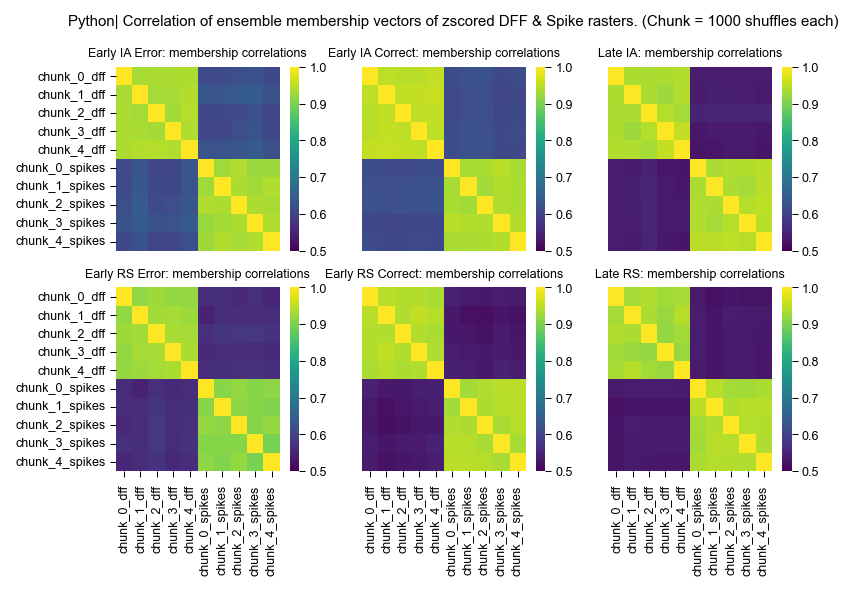

In [ ]:

merged_enriched_chunks = pd.merge(enriched_by_chunk_dff, enriched_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))
# Plot correlation heatmaps
value_compared = "membership"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merged_enriched_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merged_enriched_chunks.columns if 'chunk_' in c], value_compared=value_compared, axes = axes)
fig.suptitle(f"Python| Correlation of ensemble {value_compared} vectors of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

Figure saved: dff_vs_spikes_ensemble_p-value_vector_chunkcorrs.jpg | In: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results


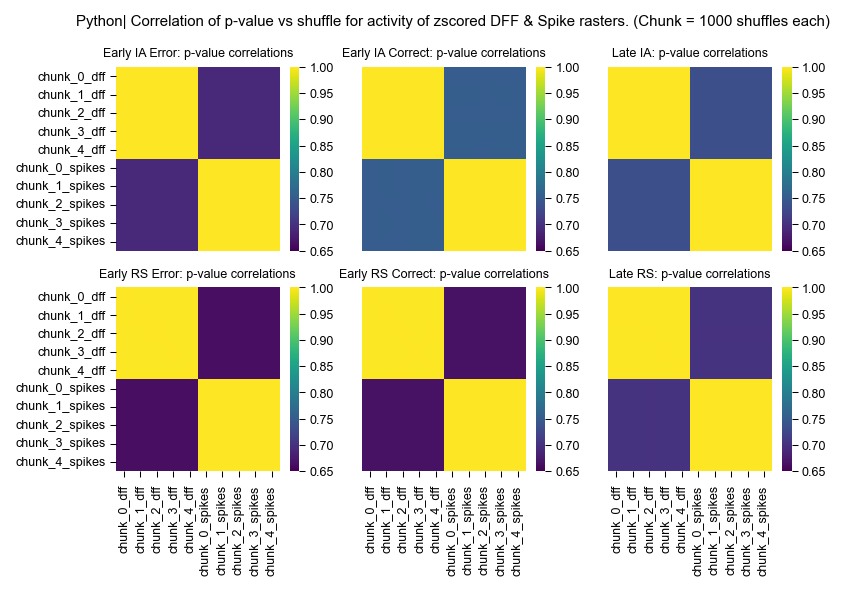

In [ ]:
#use pvalue for corr 
pval_by_chunk_spikes = get_pivoted_enrichment_heatmap(all_chunk_ens_spikes, pivot_values = 'percent_shuffle >= real')
pval_by_chunk_dff = get_pivoted_enrichment_heatmap(all_chunk_ens_dff, pivot_values = 'percent_shuffle >= real')
merge_pval_chunks = pd.merge(pval_by_chunk_dff, pval_by_chunk_spikes, on=['subject_name', 'task_stage', 'cell'], suffixes=('_dff', '_spikes'))

# Plot correlation heatmaps
value_compared = "p-value"
fig, axes = plt.subplots(2, 3, figsize=(6,3.5))
plot_stage_correlation_heatmaps(enrich_compared_df=merge_pval_chunks, stage_names=stage_names, merge_chunk_col=[c for c in merge_pval_chunks.columns if 'chunk_' in c], value_compared=value_compared, vmin = 0.65, axes = axes)
fig.suptitle(f"Python| Correlation of {value_compared} vs shuffle for activity of zscored DFF & Spike rasters. (Chunk = 1000 shuffles each)")
# Save figure
fig_filename = f"dff_vs_spikes_ensemble_{value_compared}_vector_chunkcorrs.jpg"
fig.savefig(results_dir / fig_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved: {fig_filename} | In: {results_dir}")

#### import both DFF & spike ensemble parquets


In [ ]:
# import DFF ensemble matrix- baseline Zscored
dff_ens_path = list(get_latest_shuffle_folder(results_dir, 'dff').parent.glob("*.parquet"))[0]
print(f"loading: {dff_ens_path}")
# dff_ens_path = results_dir / Path(r"dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_5000 shuffles\dff_postoutcome_python_ensembles_5000_shuff_07-Dec-2025_.parquet")
dff_ens = pd.read_parquet(dff_ens_path)
if 'data_type' not in dff_ens.columns:
    dff_ens['data_type'] = 'dff'
print(dff_ens.info())
#get ensemble info from canon df
dff_ens.tail(3)

loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\dff_baseline_zscore_norm_ensemble_detection_07-Dec-2025_10000 shuffles\dff_postoutcome_python_ensembles_10000_shuff_07-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39534 entries, 0 to 39533
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               39534 non-null  object 
 1   cell                     39534 non-null  object 
 2   percentile_95            39520 non-null  float64
 3   mean                     39520 non-null  float32
 4   enriched                 39534 non-null  bool   
 5   percent_shuffle >= real  39534 non-null  float64
 6   subject_name             39534 non-null  object 
 7   neuron_id                39534 non-null  object 
 8   date_made                39534 non-null  object 
 9   n_shuffles               39534 non-null  int64  
 10  data_type 

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
39531,Late_IA,cell_215,0.661995,-0.354924,False,0.9983,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39532,Late_RS,cell_215,0.726587,0.001032,False,0.3358,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff
39533,truncated_post_outcome,cell_215,0.174152,-0.165721,False,0.9979,9_3_HET_RS3,9_3_HET_RS3-215,07-Dec-2025,10000,dff


In [ ]:
#import last spikes ensemble matrix for comparison
#non normalized mean spike rate for the means 
spikes_ens_path = list(get_latest_shuffle_folder(results_dir, 'raster').parent.glob("*.parquet"))[0]
print(f"Loading: {spikes_ens_path}") # spikes_ens_path = results_dir / Path(r"raster_none_norm_ensemble_detection_06-Dec-2025_5000 shuffles\raster_postoutcome_python_ensembles_5000_shuff_06-Dec-2025_.parquet")
spikes_ens = pd.read_parquet(spikes_ens_path)
if 'data_type' not in spikes_ens.columns:
    spikes_ens['data_type'] = 'spikes'
print(spikes_ens.info())
spikes_ens.tail(3)

Loading: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\raster_none_norm_ensemble_detection_08-Dec-2025_10000 shuffles\raster_postoutcome_python_ensembles_10000_shuff_08-Dec-2025_.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38199 entries, 0 to 38198
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   task_stage               38199 non-null  object 
 1   cell                     38199 non-null  object 
 2   percentile_95            38199 non-null  float64
 3   mean                     38199 non-null  float64
 4   enriched                 38199 non-null  bool   
 5   percent_shuffle >= real  38199 non-null  float64
 6   subject_name             38199 non-null  object 
 7   neuron_id                38199 non-null  object 
 8   date_made                38199 non-null  object 
 9   n_shuffles               38199 non-null  int64  
 10  data_type      

,task_stage,cell,percentile_95,mean,enriched,percent_shuffle >= real,subject_name,neuron_id,date_made,n_shuffles,data_type
38196,Late_IA,cell_99,0.017333,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster
38197,Late_RS,cell_99,0.018333,0.000000,False,1.0000,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster
38198,truncated_post_outcome,cell_99,0.006127,0.002014,False,0.6078,9_3_HET_RS3,9_3_HET_RS3-99,08-Dec-2025,10000,raster


In [ ]:
## pivot both enrichment vectors, then merge
spikes_ens_matrix = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
dff_ens_matrix = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'enriched', fill_value = None).astype(float)
compare_spike_dff_ens = spikes_ens_matrix.merge(dff_ens_matrix, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_ens.info())
compare_spike_dff_ens.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          4441 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             4441 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
10_3_HET_RS1-100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df = compare_spike_dff_ens
correlations = {stage: df[stage+"_spikes"].corr(df[stage + '_dff']) for stage in stage_names}
corr_df = pd.DataFrame.from_dict(correlations, orient='index', columns=['Correlation'])
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.624613
Early_IA_Correct     0.614595
Late_IA              0.550077
Early_RS_Error       0.574041
Early_RS_Correct     0.525900
Late_RS              0.535796


In [ ]:
## pivot both p-value matrices, then merge
spikes_ens_pval = spikes_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
dff_ens_pval = dff_ens.pivot_table(index = ['neuron_id'], columns = 'task_stage', values = 'percent_shuffle >= real', fill_value = False).astype(float)
compare_spike_dff_p = spikes_ens_pval.merge(dff_ens_pval, on = 'neuron_id', suffixes=('_spikes', '_dff'))
print(compare_spike_dff_p.info())
compare_spike_dff_p.head(3)

<class 'pandas.core.frame.DataFrame'>
Index: 5470 entries, 10_3_HET_RS1-1 to 9_3_HET_RS3-99
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Early_IA_Correct_spikes        5470 non-null   float64
 1   Early_IA_Error_spikes          5470 non-null   float64
 2   Early_RS_Correct_spikes        5470 non-null   float64
 3   Early_RS_Error_spikes          5470 non-null   float64
 4   Late_IA_spikes                 5470 non-null   float64
 5   Late_RS_spikes                 5470 non-null   float64
 6   truncated_post_outcome_spikes  5470 non-null   float64
 7   Early_IA_Correct_dff           5470 non-null   float64
 8   Early_IA_Error_dff             5470 non-null   float64
 9   Early_RS_Correct_dff           5470 non-null   float64
 10  Early_RS_Error_dff             5470 non-null   float64
 11  Late_IA_dff                    5470 non-null   float64
 12  Late_RS_dff                   

task_stage,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes,truncated_post_outcome_spikes,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,truncated_post_outcome_dff
neuron_id,,,,,,,,,,,,,,
10_3_HET_RS1-1,0.2420,0.0008,1.0000,1.0,1.0,1.0,0.0150,0.3701,0.0007,0.2501,0.7499,0.5230,0.7730,0.0118
10_3_HET_RS1-10,0.2525,0.0013,1.0000,1.0,1.0,1.0,0.0017,0.1555,0.0046,1.0000,0.0548,0.9665,0.7555,0.0001
10_3_HET_RS1-100,1.0000,1.0000,0.4383,1.0,1.0,1.0,0.7576,0.9762,0.8332,0.6920,0.9575,0.9946,0.9888,0.9445


In [ ]:
corr_df = get_intercol_corrs(compare_spike_dff_p, stage_names, suffix1="_spikes", suffix2="_dff")
print(f" Correlation of enrichment vectors for DFF data vs SPIKE data: \n{corr_df}")

 Correlation of enrichment vectors for DFF data vs SPIKE data: 
                  Correlation
Early_IA_Error       0.782424
Early_IA_Correct     0.753088
Late_IA              0.734657
Early_RS_Error       0.663554
Early_RS_Correct     0.666088
Late_RS              0.702068


#### Threshold time-series df to remove 0 

In [ ]:
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import annotate_csv, run_min_max_norm_on_timeseries
